In [2]:
# import and clean a large data set
import pandas as pd

large_data_set= pd.read_csv(r"C:\Users\fatima28\Downloads\archive\college_students_habits_1M.csv", encoding='utf-8')


In [2]:
# check high of score and min and mean
print(large_data_set['final_score'].mean())
print(large_data_set['final_score'].max())
print(large_data_set['final_score'].min())



64.85610525538743
100.0
0.0


In [ ]:
# check the total rows and columns ,datatypes and NAN values
large_data_set.info()

In [ ]:
large_data_set.loc[:,'performance_level'].tail(200)

In [ ]:
# check null values 
# boolean masking
null_val=large_data_set["performance_level"].isna()
print(type(null_val))
# print(null_val)
large_data_set.loc[null_val,['performance_level','stress']]

In [3]:
# check attendecnce > 75%
high_attendence = large_data_set['attendance']>=75# boolean masking
# 
print(type(high_attendence))
# print()
large_data_set.loc[high_attendence ,['attendance','final_score']]

<class 'pandas.Series'>


,attendance,final_score
6,82.386530,71.327520
7,100.000000,90.172585
10,78.555680,76.216354
12,87.266914,77.344090
17,78.776130,68.554886
...,...,...
999986,81.196380,67.673460
999989,79.104610,59.898945
999990,79.751540,74.084050
999991,77.384740,71.225430


In [2]:
lower_atten = large_data_set['attendance']<75

large_data_set.loc[lower_atten,['attendance','final_score']]


,attendance,final_score
0,67.005990,61.653540
1,73.284550,62.062782
2,72.325190,46.482760
3,74.756870,55.448948
4,55.050210,32.378000
...,...,...
999994,59.558132,43.694530
999996,68.391780,61.635914
999997,67.135370,54.084050
999998,72.576324,61.578785


In [13]:
if large_data_set.loc[lower_atten,'final_score'].mean() > large_data_set.loc[:,'final_score'].mean():

    print('attandace not affect on final score')
    print(large_data_set.loc[lower_atten,'final_score'].mean() )
else:
    print('lower attendance  affect on final score')
    print(large_data_set.loc[lower_atten,'final_score'].mean()) 



lower attendance  affect on final score
51.41721007168272


In [22]:
# comapre final score beteen lower and high attendance
if large_data_set.loc[lower_atten,'final_score'].mean() < large_data_set.loc[high_attendence,'final_score'].mean():
    print(' lower attendance afftect on final score ')
    print({large_data_set.loc[lower_atten,'final_score'].mean()})
else:
    print(f'high attendacne dees not affect on high attendance')
    print( {large_data_set.loc[high_attendence,'final_score'].mean()})
    



 lower attendance afftect on final score 
{np.float64(51.41721007168272)}


In [ ]:
a=large_data_set.loc[lower_atten,'final_score']
type(a)
a

stage 2 aggregation and insights
use groupby()
it perfome 3 steps
1 split: it split the data into given columns sepratly
2 apply : perfome on each grp /col the given calculation exmple : mean,sum
3 combine : combine the all result into a summary



check the stress level according to backlog 


In [45]:
# large_data_set['performance_level'].unique()
large_data_set['backlogs'].unique()



array([ 4,  3,  2,  5,  1,  0,  7,  6,  8, 10,  9])

In [ ]:
!pip install matplotlib

In [1]:
large_data_set.groupby(by='backlogs')[['stress','study_hours','sleep_hours','anxiety']].mean()

NameError: name 'large_data_set' is not defined

<Axes: title={'center': 'summary of stress'}, xlabel='anxity', ylabel='stress'>

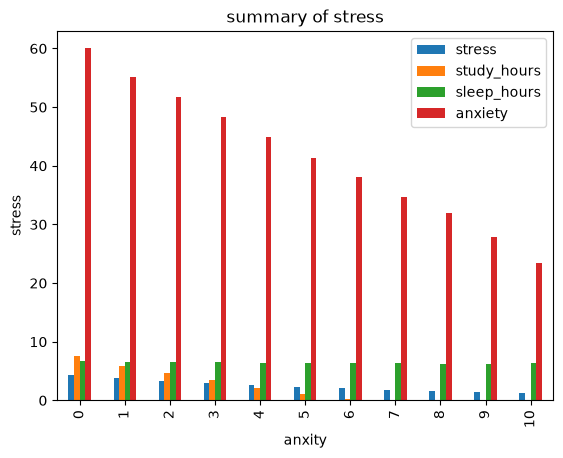

In [ ]:
# lets check the summary of 11 baclogs stress level
import matplotlib.pyplot


large_data_set.groupby(by='backlogs')[['stress','study_hours','sleep_hours','anxiety']].mean().plot(kind='bar',title='summary of stress',ylabel='stress',xlabel='anxity')

In [10]:
# save data of high attendance into csv file
data_f=large_data_set.loc[high_attendence,  ['attendance',     'stress']]

data_f.to_csv('high_attendecne_clean.csv',index=False)